# Benchmark OneHotEncoder

Ce notebook compare les performances de l'implémentation personnalisée `OneHotEncoder` de `ifri_mini_ml_lib` avec celle de scikit-learn.

## Objectifs
- Mesurer le temps d'exécution pour `fit` et `transform`.
- Mesurer l'utilisation de la mémoire.
- Comparer la scalabilité aux tailles croissantes.
- Vérifier les entrées acceptées et la robustesse/gestion des erreurs.
- Vérifier la cohérence des résultats.

In [27]:
import pandas as pd
import numpy as np
import time
import tracemalloc
import sys
import os
from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from ifri_mini_ml_lib.preprocessing import OneHotEncoder as CustomOneHotEncoder

# Dataset de taille modérée (pas 1M, 10k est suffisant)
n_samples = 10_000
categories = ['Cat_A', 'Cat_B', 'Cat_C', 'Cat_D', 'Cat_E', 'Cat_F']

df = pd.DataFrame({
    'category_1': np.random.choice(categories, n_samples),
    'category_2': np.random.choice(categories, n_samples),
    'value': np.random.rand(n_samples)
})

print(f"Dataset : {n_samples} lignes, 3 colonnes (2 catégorielles + 1 numérique)")
print(df.head())

Dataset : 10000 lignes, 3 colonnes (2 catégorielles + 1 numérique)
  category_1 category_2     value
0      Cat_C      Cat_E  0.395733
1      Cat_E      Cat_E  0.658494
2      Cat_E      Cat_D  0.110237
3      Cat_E      Cat_E  0.372484
4      Cat_F      Cat_A  0.037623


In [31]:
# Fonction utilitaire pour benchmark
def benchmark_encoder(name, encoder_func, df_input):
    tracemalloc.start()
    start = time.time()
    result = encoder_func(df_input)
    end = time.time()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {
        'Encodeur': name,
        'Temps (s)': end - start,
        'Mémoire pic (MB)': peak / (1024**2),
        'Shape': result.shape
    }

# 1. Scikit-learn OneHotEncoder
def sklearn_encode(df):
    enc = SklearnOneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded = enc.fit_transform(df[['category_1', 'category_2']])
    return pd.DataFrame(encoded, columns=enc.get_feature_names_out())

r_sklearn = benchmark_encoder('Scikit-learn', sklearn_encode, df)

# 2. Custom OneHotEncoder
def custom_encode(df):
    enc = CustomOneHotEncoder(handle_unknown='ignore')
    return enc.fit_transform(df)

r_custom = benchmark_encoder('Custom', custom_encode, df)

# Tableau comparatif
results = pd.DataFrame([r_sklearn, r_custom])
print(results.to_string(index=False))

    Encodeur  Temps (s)  Mémoire pic (MB)       Shape
Scikit-learn   0.122438          1.741947 (10000, 12)
      Custom   0.133162          2.255952 (10000, 13)


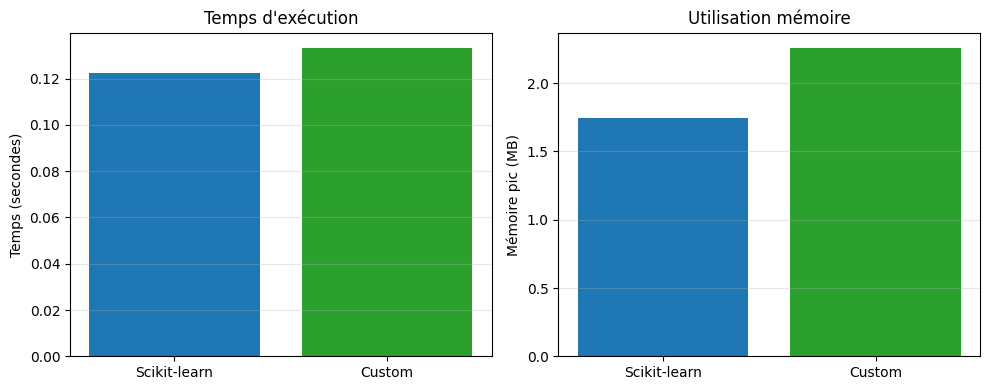


Conclusions :
- Encodeur le plus rapide : Scikit-learn
- Avantage Custom : encode les colonnes numériques en plus des catégories


In [32]:
# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Temps d'exécution
axes[0].bar(results['Encodeur'], results['Temps (s)'], color=['#1f77b4', '#2ca02c'])
axes[0].set_ylabel('Temps (secondes)')
axes[0].set_title('Temps d\'exécution')
axes[0].grid(axis='y', alpha=0.3)

# Mémoire
axes[1].bar(results['Encodeur'], results['Mémoire pic (MB)'], color=['#1f77b4', '#2ca02c'])
axes[1].set_ylabel('Mémoire pic (MB)')
axes[1].set_title('Utilisation mémoire')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusions :")
fastest = results.loc[results['Temps (s)'].idxmin(), 'Encodeur']
print(f"- Encodeur le plus rapide : {fastest}")
print(f"- Avantage Custom : encode les colonnes numériques en plus des catégories")

In [30]:
# Test de robustesse - Gestion des catégories inconnues
test_input = pd.DataFrame({
    'category_1': ['Cat_A', 'Cat_Unknown'],
    'category_2': ['Cat_B', 'Cat_C'],
    'value': [1, 2]
})

print("Test robustesse - Catégorie inconnue 'Cat_Unknown' en mode ignore:\n")

try:
    custom_result = CustomOneHotEncoder(handle_unknown='ignore').fit(df).transform(test_input)
    print(f"✓ Custom : shape={custom_result.shape}")
except Exception as e:
    print(f"✗ Custom : {type(e).__name__}")

try:
    enc_sklearn = SklearnOneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc_sklearn.fit(df[['category_1', 'category_2']])
    sklearn_result = enc_sklearn.transform(test_input[['category_1', 'category_2']])
    print(f"✓ Scikit-learn : shape={sklearn_result.shape}")
except Exception as e:
    print(f"✗ Scikit-learn : {type(e).__name__}")

Test robustesse - Catégorie inconnue 'Cat_Unknown' en mode ignore:

✓ Custom : shape=(2, 13)
✓ Scikit-learn : shape=(2, 12)
